# 01. 데이터 탐색 (EDA)
## Playground Series S6E8 — Predicting Smartphone Addiction

**목표**: 모델을 만들기 전에 데이터가 "어떻게 생겼는지" 눈으로 파악한다.

EDA(Exploratory Data Analysis, 탐색적 데이터 분석)는 요리로 치면 **재료 검수**다.
어떤 재료가 있고, 상한 건 없는지(결측치), 양이 치우치진 않았는지(분포)를 먼저 봐야
어떻게 요리할지(전처리·모델링)를 정할 수 있다.

### 이 노트북에서 답할 질문 6가지
1. 데이터는 몇 행 몇 열이고, 무엇을 맞히는 문제인가?
2. 결측치는 얼마나 있는가?
3. 수치형 변수들의 분포는 어떤가?
4. 범주형 변수는 타깃과 관계가 있는가?
5. 변수끼리 서로 얼마나 겹치는가(상관관계)?
6. **결측이라는 사실 자체**가 정보가 되는가?

## 0. 준비 — 라이브러리 불러오기

In [1]:
# 데이터 처리
import numpy as np                  # 수치 연산 (배열, 평균, 표준편차 등)
import pandas as pd                 # 표 형태 데이터를 다루는 표준 도구

# 시각화
import matplotlib.pyplot as plt     # 모든 파이썬 그래프의 기반 라이브러리
import seaborn as sns               # matplotlib을 감싼 도구. 통계 그래프를 짧은 코드로

import warnings
warnings.filterwarnings('ignore')   # 분석에 지장 없는 경고 메시지 숨기기

# 그래프 기본 설정
# Windows에서 한글이 네모(ㅁ)로 깨지는 것을 막아준다
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')                   # 흰 배경 + 옅은 격자선 스타일

# 재현성 확보
# 같은 코드를 다시 돌려도 같은 결과가 나오도록 난수 시드를 고정한다.
# 이걸 안 하면 "점수가 오른 것"인지 "운이 좋았던 것"인지 구분할 수 없다.
SEED = 42
np.random.seed(SEED)

# 표를 출력할 때 잘리지 않도록
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)

print('준비 완료')
print(f'pandas {pd.__version__} / numpy {np.__version__}')

준비 완료
pandas 3.0.5 / numpy 2.4.6


## 1. 데이터 불러오기 & 첫인상

In [2]:
# read_csv: CSV 파일을 DataFrame(표)으로 읽어들이는 함수
DATA = '../data/'

train = pd.read_csv(DATA + 'train.csv')
test  = pd.read_csv(DATA + 'test.csv')
sub   = pd.read_csv(DATA + 'sample_submission.csv')

# .shape -> (행 개수, 열 개수) 튜플을 반환
print(f'train : {train.shape[0]:,} 행 x {train.shape[1]} 열')
print(f'test  : {test.shape[0]:,} 행 x {test.shape[1]} 열')
print(f'sub   : {sub.shape[0]:,} 행 x {sub.shape[1]} 열')

train : 691,369 행 x 14 열
test  : 296,302 행 x 13 열
sub   : 296,302 행 x 2 열


In [3]:
# .head(n) -> 위에서 n개 행만 미리보기 (기본값 5)
train.head()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


In [4]:
# train에는 있고 test에는 없는 열 = 우리가 맞혀야 할 정답(타깃)
TARGET = [col for col in train.columns if col not in test.columns][0]
print(f'타깃 변수: {TARGET}')

# 제출 파일 형태 확인 -> 무엇을 어떤 형식으로 내야 하는지 알려준다
print()
print('[ sample_submission 미리보기 ]')
print(sub.head(3))

타깃 변수: addicted_label

[ sample_submission 미리보기 ]
       id  addicted_label
0  691369        0.709424
1  691370        0.709424
2  691371        0.709424


> **중요한 관찰**
>
> `sample_submission`의 값이 `0`/`1`이 아니라 **0.709424 같은 소수**다.
> 즉 "중독이다/아니다"를 단정하는 게 아니라 **중독일 확률**을 제출하는 문제다.
> 이런 경우 평가 지표는 보통 **ROC-AUC**다.
> (대회 페이지 Evaluation 탭에서 반드시 확인할 것)

In [5]:
# 분석 편의를 위해 열을 역할별로 나눠 이름표를 붙여둔다.
# 리스트로 정의해두면 뒤에서 반복 작업할 때 편하다.
NUM_COLS = [
    'age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours',
    'work_study_hours', 'sleep_hours', 'notifications_per_day',
    'app_opens_per_day', 'weekend_screen_time',
]
CAT_COLS = ['gender', 'stress_level', 'academic_work_impact']

print(f'수치형 변수 {len(NUM_COLS)}개: {NUM_COLS}')
print(f'범주형 변수 {len(CAT_COLS)}개: {CAT_COLS}')
print(f'식별자: id  |  타깃: {TARGET}')

수치형 변수 9개: ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time']
범주형 변수 3개: ['gender', 'stress_level', 'academic_work_impact']
식별자: id  |  타깃: addicted_label


## 2. 타깃 분포 — 클래스 불균형 확인

addicted_label
0    200895
1    490474
Name: count, dtype: int64

양성(중독=1) 비율: 0.7094  ->  약 70.9%


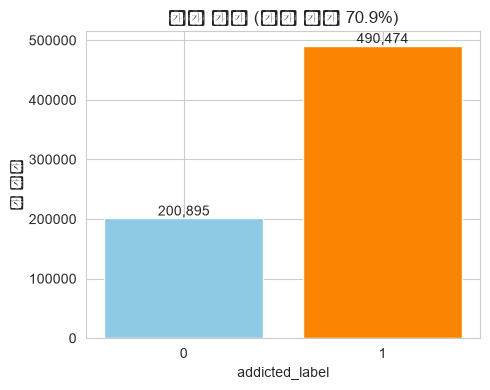

In [6]:
# .value_counts() -> 각 값이 몇 번 나오는지 세어준다
counts = train[TARGET].value_counts().sort_index()
ratio  = train[TARGET].mean()   # 0과 1로 된 열의 평균 = 1의 비율

print(counts)
print()
print(f'양성(중독=1) 비율: {ratio:.4f}  ->  약 {ratio*100:.1f}%')

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(counts.index.astype(str), counts.values, color=['#8ecae6', '#fb8500'])
ax.set_title(f'타깃 분포 (양성 비율 {ratio:.1%})')
ax.set_xlabel('addicted_label')
ax.set_ylabel('행 개수')
for i, v in enumerate(counts.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom')
plt.tight_layout(); plt.show()

### 해석

약 **71% 대 29%** 로 한쪽이 많은 **불균형(imbalanced) 데이터**다.

- 무조건 "중독(1)"이라고만 찍어도 **정확도(Accuracy) 71%** 가 나온다.
  그래서 이 문제에서 정확도는 쓸모없는 지표다.
- **ROC-AUC**는 "양성을 음성보다 높은 점수로 매길 확률"을 재기 때문에
  이런 불균형에 훨씬 덜 속는다.
- 다만 3:7 정도는 **심한 불균형은 아니다.** 오버샘플링(SMOTE) 같은 기법까지
  동원할 필요는 없고, 나중에 LightGBM의 `scale_pos_weight` 정도만
  실험해보면 충분하다.

참고로 `sample_submission`의 상수값 0.709424가 바로 이 양성 비율이다.
캐글이 "아무 정보 없이 낼 수 있는 최소한의 답"을 기본값으로 준 것이다.

## 3. 결측치 — 이 대회의 핵심 난관

In [7]:
# .isnull() -> 각 칸이 비었는지 True/False 표를 만든다
# .sum()    -> True를 1로 세어 열별 결측 개수를 구한다
# .mean()   -> True 비율 = 결측률
miss = pd.DataFrame({
    '결측개수': train.isnull().sum(),
    '결측률(%)': (train.isnull().mean() * 100).round(2),
})
miss = miss[miss['결측개수'] > 0].sort_values('결측률(%)', ascending=False)
miss

,결측개수,결측률(%)
social_media_hours,133995,19.38
gaming_hours,126821,18.34
weekend_screen_time,112063,16.21
daily_screen_time_hours,95854,13.86
app_opens_per_day,80710,11.67
notifications_per_day,67584,9.78
stress_level,55148,7.98
work_study_hours,51518,7.45
sleep_hours,44480,6.43
academic_work_impact,44224,6.40


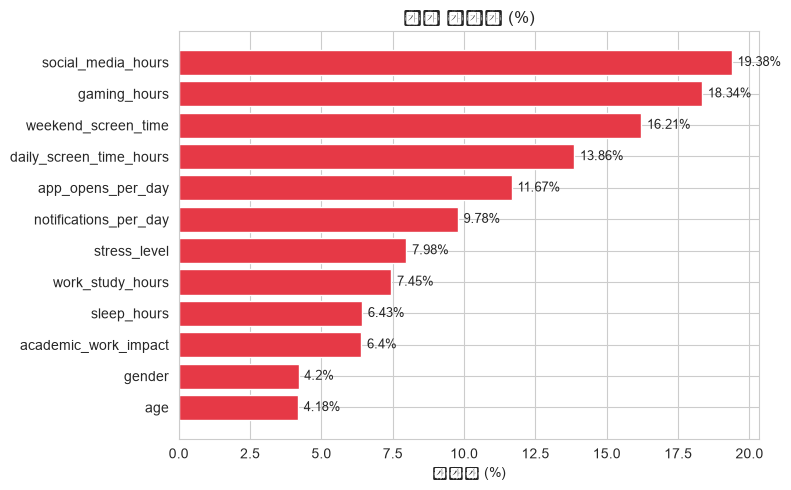

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(miss.index[::-1], miss['결측률(%)'][::-1], color='#e63946')
ax.set_title('열별 결측률 (%)')
ax.set_xlabel('결측률 (%)')
for i, v in enumerate(miss['결측률(%)'][::-1]):
    ax.text(v + 0.2, i, f'{v}%', va='center', fontsize=9)
plt.tight_layout(); plt.show()

In [9]:
# train과 test의 결측 패턴이 비슷한지 확인한다.
# 크게 다르면 "train에서 배운 처리 방식이 test에서 안 통하는" 문제가 생긴다.
cmp = pd.DataFrame({
    'train 결측률(%)': (train.isnull().mean() * 100).round(2),
    'test 결측률(%)' : (test.isnull().mean() * 100).round(2),
}).drop(index=['id', TARGET], errors='ignore')
cmp['차이(train-test)'] = (cmp['train 결측률(%)'] - cmp['test 결측률(%)']).round(2)
cmp.sort_values('차이(train-test)')

,train 결측률(%),test 결측률(%),차이(train-test)
academic_work_impact,6.40,8.68,-2.28
work_study_hours,7.45,9.37,-1.92
notifications_per_day,9.78,11.55,-1.77
gaming_hours,18.34,20.05,-1.71
age,4.18,5.78,-1.60
sleep_hours,6.43,7.58,-1.15
weekend_screen_time,16.21,17.11,-0.90
gender,4.20,4.80,-0.60
stress_level,7.98,6.62,1.36
daily_screen_time_hours,13.86,11.07,2.79


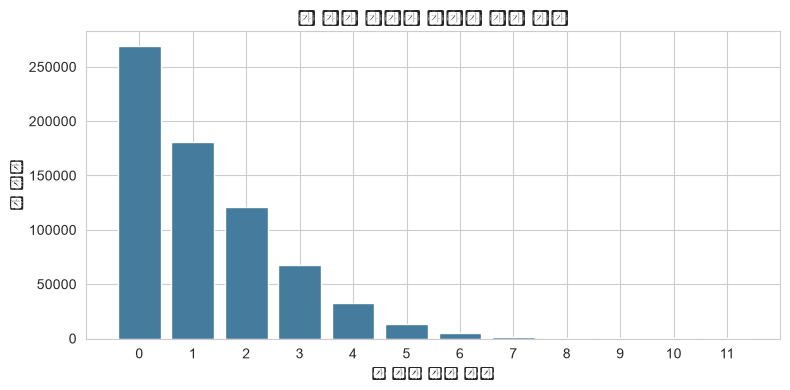

결측이 하나도 없는 행: 269,185 개 (38.9%)
-> 결측 있는 행을 전부 버리면 데이터의 61.1% 를 잃는다.


In [10]:
# 한 행(=한 사람)에 결측이 몇 개나 있는지 세어본다.
# axis=1 은 "가로 방향으로 합산" = 행 단위 집계를 뜻한다.
n_missing = train[NUM_COLS + CAT_COLS].isnull().sum(axis=1)
dist = n_missing.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(dist.index.astype(str), dist.values, color='#457b9d')
ax.set_title('한 행에 포함된 결측치 개수 분포')
ax.set_xlabel('그 행의 결측 개수')
ax.set_ylabel('행 개수')
plt.tight_layout(); plt.show()

perfect = dist.get(0, 0)
print(f'결측이 하나도 없는 행: {perfect:,} 개 ({perfect/len(train):.1%})')
print(f'-> 결측 있는 행을 전부 버리면 데이터의 {1-perfect/len(train):.1%} 를 잃는다.')

### 해석 — 결측치를 어떻게 다룰 것인가

결측률이 **4%~19%** 로 전 열에 걸쳐 넓게 퍼져 있다. 그리고 결측이 하나도 없는 행은
전체의 **39%뿐**이다.

- ❌ **행 삭제(`dropna`)는 절대 안 된다.** 데이터의 61%를 버리게 된다.
- ✅ **채워 넣기(imputation)** 가 정답이다. 02단계에서 다룬다.
- ✅ **LightGBM은 결측치를 그대로 학습할 수 있다.** 트리 모델은 "값이 없으면
  어느 쪽 가지로 보낼지"를 스스로 학습한다. 그래서 03단계 베이스라인에서는
  아무것도 채우지 않고 그냥 넣어보는 것이 좋은 비교군이 된다.

train과 test의 결측률 차이가 작으므로, 같은 방식으로 처리해도 안전하다.

## 4. 수치형 변수 분포

In [11]:
# .describe() -> 개수, 평균, 표준편차, 최소/사분위/최대값을 한 번에
# .T (transpose) -> 행과 열을 뒤집어 읽기 편하게
train[NUM_COLS].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,662440.0,26.62,5.15,18.00,22.00,27.00,31.00,35.00
daily_screen_time_hours,595515.0,7.64,2.72,0.50,5.48,7.77,9.84,15.00
social_media_hours,557374.0,2.47,1.32,0.00,1.45,2.31,3.37,8.00
gaming_hours,564548.0,1.46,0.93,0.00,0.70,1.33,2.09,4.00
work_study_hours,639851.0,2.37,1.26,0.00,1.36,2.20,3.20,6.00
sleep_hours,646889.0,6.80,1.23,4.50,5.78,6.80,7.87,9.00
notifications_per_day,623785.0,145.89,65.92,20.00,93.00,150.00,204.00,250.00
app_opens_per_day,610659.0,102.64,48.09,15.00,64.00,104.00,145.00,180.00
weekend_screen_time,579306.0,9.48,2.86,0.51,7.28,9.58,11.75,17.56


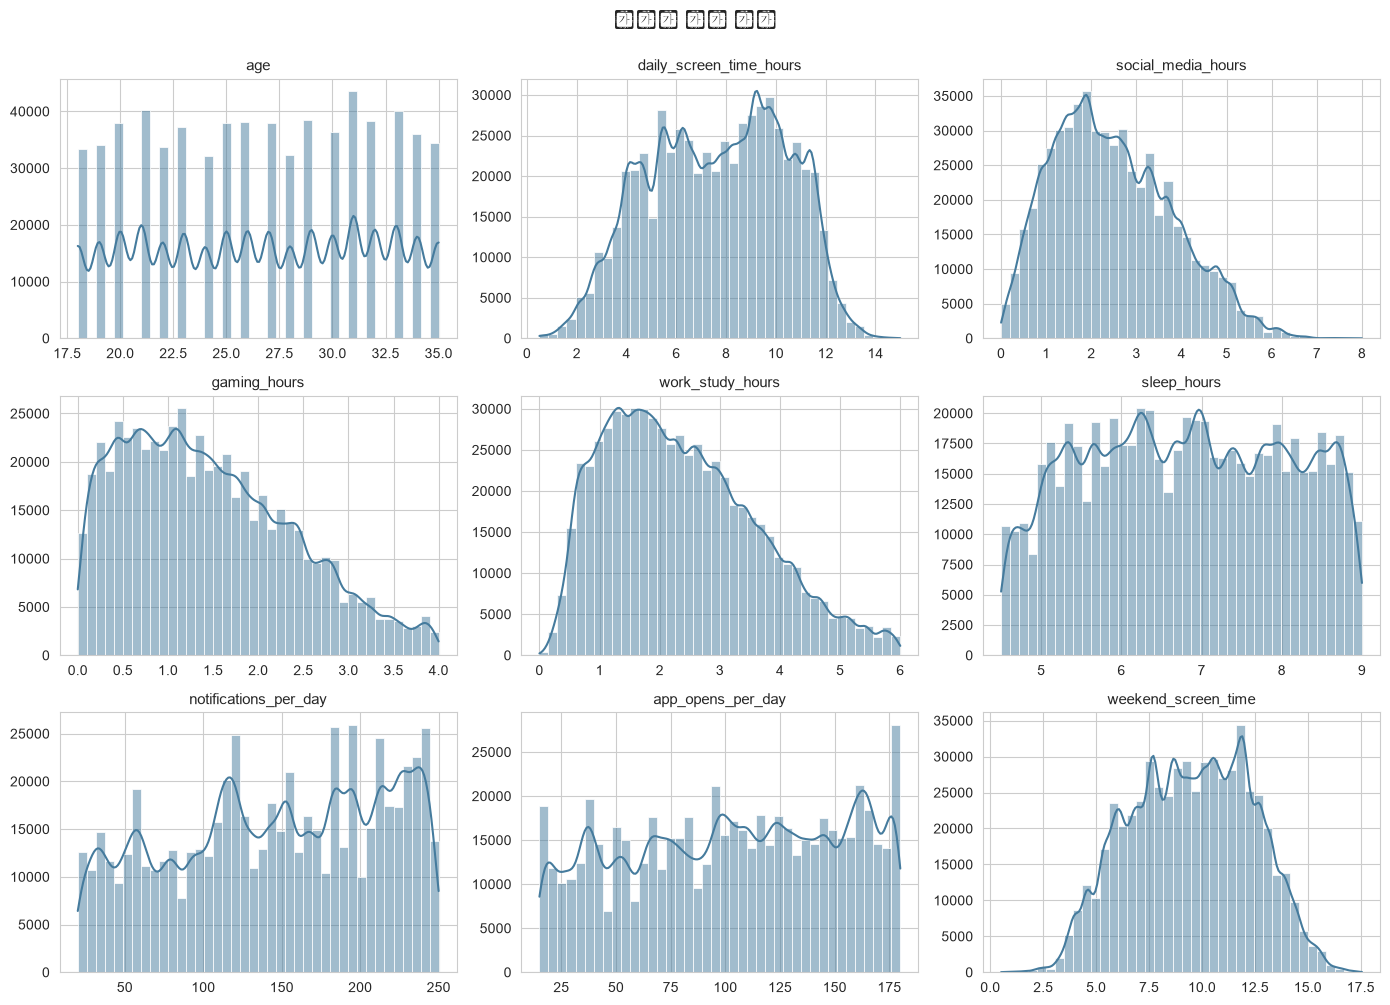

In [12]:
# 변수 9개의 분포를 한 화면에 그린다 (3행 x 3열 격자)
fig, axes = plt.subplots(3, 3, figsize=(14, 10))

# .ravel() -> 3x3 격자를 1차원으로 펴서 for문으로 돌리기 쉽게 만든다
for col, ax in zip(NUM_COLS, axes.ravel()):
    # histplot: 값의 구간별 개수를 막대로. kde=True면 부드러운 곡선도 함께
    sns.histplot(train[col].dropna(), bins=40, kde=True, ax=ax, color='#457b9d')
    ax.set_title(col, fontsize=11)
    ax.set_xlabel(''); ax.set_ylabel('')

plt.suptitle('수치형 변수 분포', fontsize=14, y=1.00)
plt.tight_layout(); plt.show()

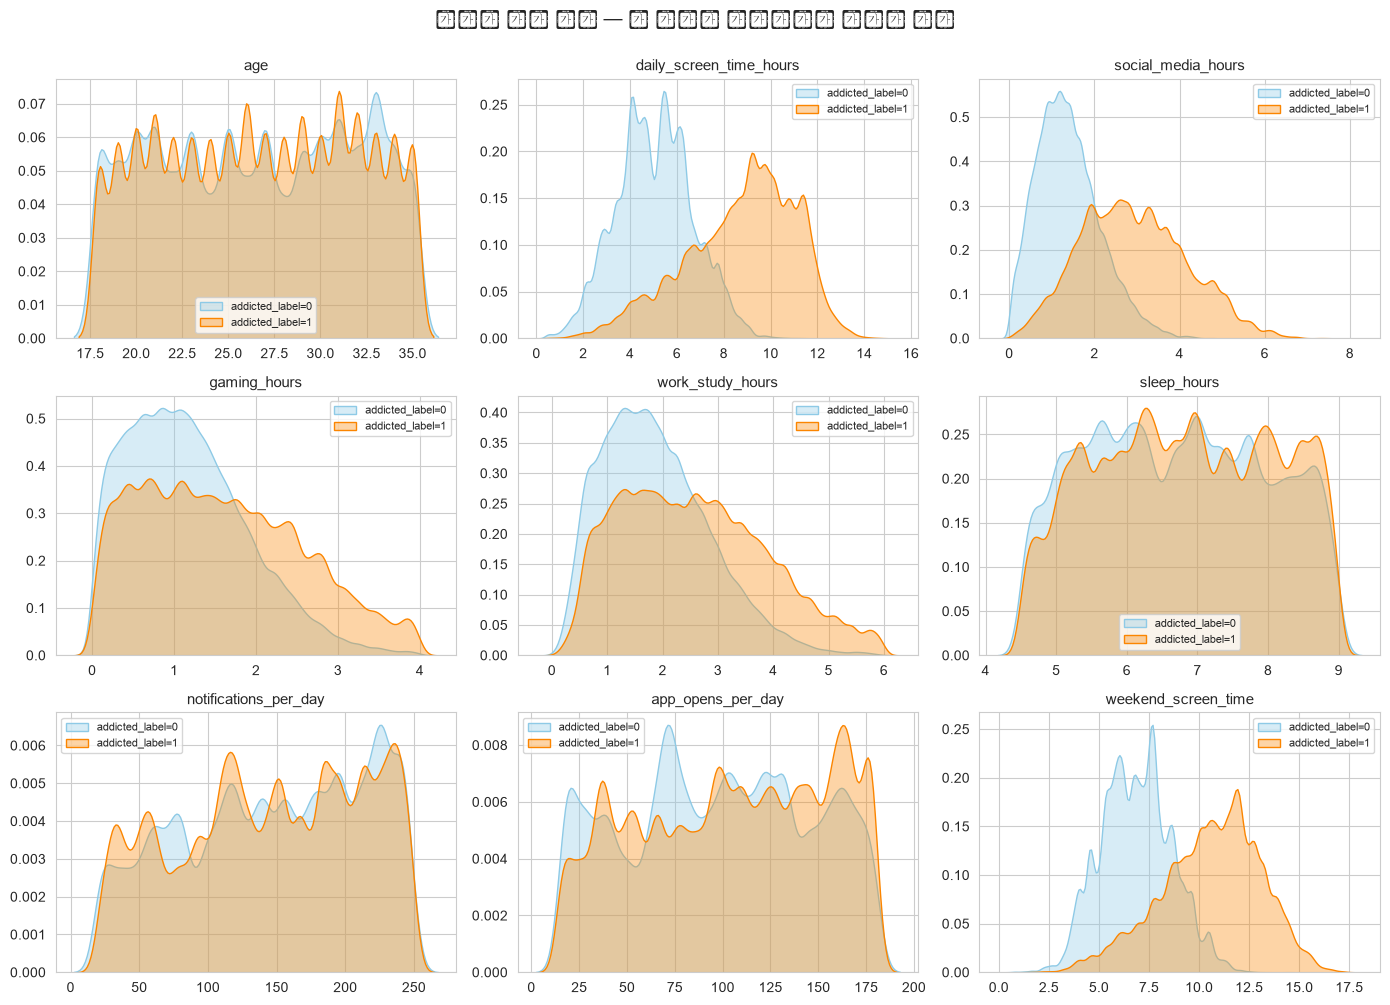

In [13]:
# 타깃(0/1)에 따라 분포가 갈리는지 본다.
# 두 곡선이 많이 어긋난 변수일수록 예측에 유용한 변수다.
fig, axes = plt.subplots(3, 3, figsize=(14, 10))

for col, ax in zip(NUM_COLS, axes.ravel()):
    for label, color in [(0, '#8ecae6'), (1, '#fb8500')]:
        subset = train.loc[train[TARGET] == label, col].dropna()
        # kdeplot: 히스토그램을 부드러운 곡선으로 표현 (분포 비교에 유리)
        sns.kdeplot(subset, ax=ax, label=f'{TARGET}={label}',
                    fill=True, alpha=0.35, color=color)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel(''); ax.set_ylabel('')
    ax.legend(fontsize=8)

plt.suptitle('타깃별 분포 비교 — 두 곡선이 어긋날수록 유용한 변수', fontsize=14, y=1.00)
plt.tight_layout(); plt.show()

In [14]:
# 눈으로 본 차이를 숫자로 확인한다.
# groupby(TARGET) -> 타깃 값별로 묶어서 각 그룹의 평균을 계산
grp = train.groupby(TARGET)[NUM_COLS].mean().T
grp.columns = ['비중독(0) 평균', '중독(1) 평균']
grp['차이'] = grp['중독(1) 평균'] - grp['비중독(0) 평균']

# 표준편차로 나눠 단위를 통일한다 (효과크기, effect size).
# 시간(0~15)과 알림수(20~250)처럼 스케일이 다른 변수를 공정하게 비교하기 위함.
grp['효과크기'] = grp['차이'] / train[NUM_COLS].std()
grp.reindex(grp['효과크기'].abs().sort_values(ascending=False).index).round(3)

,비중독(0) 평균,중독(1) 평균,차이,효과크기
daily_screen_time_hours,5.043,8.707,3.664,1.346
weekend_screen_time,6.849,10.559,3.710,1.299
social_media_hours,1.376,2.919,1.543,1.173
work_study_hours,1.873,2.570,0.697,0.554
gaming_hours,1.160,1.582,0.422,0.452
app_opens_per_day,97.871,104.593,6.721,0.140
sleep_hours,6.722,6.838,0.116,0.094
notifications_per_day,147.088,145.406,-1.682,-0.026
age,26.583,26.629,0.046,0.009


## 5. 범주형 변수와 타깃의 관계

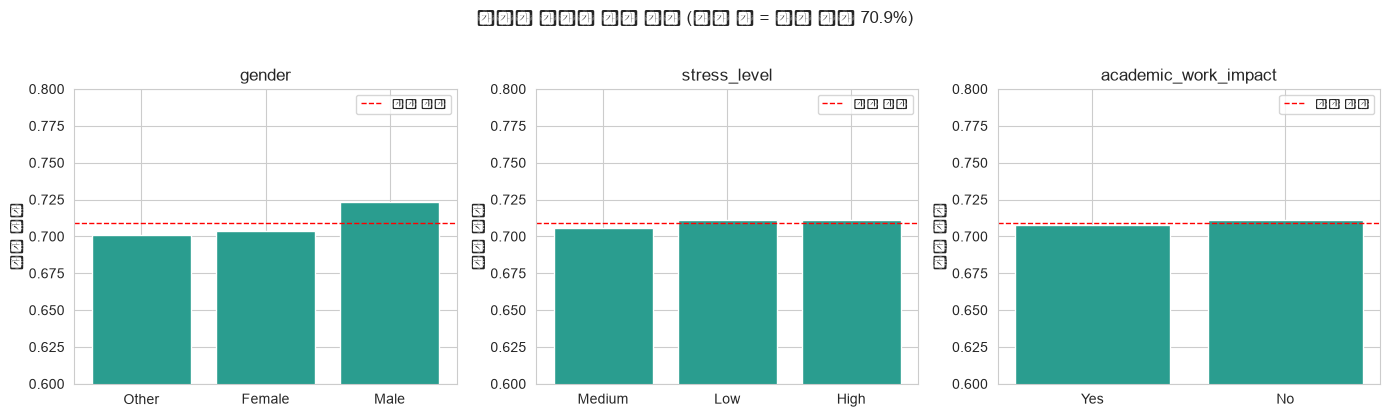

[gender]
          mean   count
gender                
Female  0.7038  221595
Male    0.7232  223662
Other   0.7010  217078

[stress_level]
                mean   count
stress_level                
High          0.7114  220873
Low           0.7112  207783
Medium        0.7057  207565

[academic_work_impact]
                        mean   count
academic_work_impact                
No                    0.7110  316579
Yes                   0.7079  330566



In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
overall = train[TARGET].mean()

for col, ax in zip(CAT_COLS, axes):
    # 카테고리별 타깃 평균 = 그 그룹의 중독 비율
    rate = train.groupby(col)[TARGET].mean().sort_values()
    ax.bar(rate.index.astype(str), rate.values, color='#2a9d8f')
    # axhline: 전체 평균선을 그어 비교 기준을 만든다
    ax.axhline(overall, color='red', ls='--', lw=1, label='전체 평균')
    ax.set_title(col)
    ax.set_ylabel('중독 비율')
    ax.set_ylim(0.6, 0.8)
    ax.legend(fontsize=8)

plt.suptitle(f'범주형 변수별 중독 비율 (빨간 선 = 전체 평균 {overall:.1%})', y=1.03)
plt.tight_layout(); plt.show()

for col in CAT_COLS:
    print(f'[{col}]')
    print(train.groupby(col)[TARGET].agg(['mean', 'count']).round(4))
    print()

## 6. 상관관계 — 변수끼리 얼마나 겹치는가

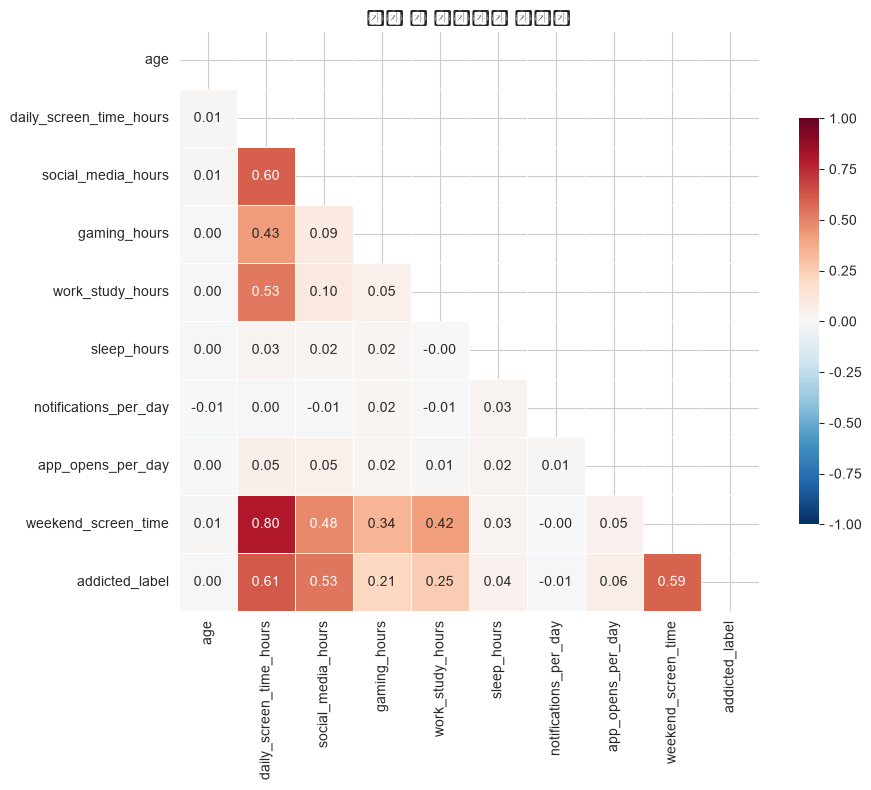

In [16]:
# .corr() -> 변수 간 피어슨 상관계수 행렬 (-1 ~ +1)
#   +1에 가까울수록 같이 커지고, -1이면 반대로 움직인다.
corr = train[NUM_COLS + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(10, 8))
# mask: 대각선 위쪽은 아래쪽과 같은 내용이라 가려서 보기 좋게 만든다
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.7}, ax=ax)
ax.set_title('변수 간 상관관계 히트맵')
plt.tight_layout(); plt.show()

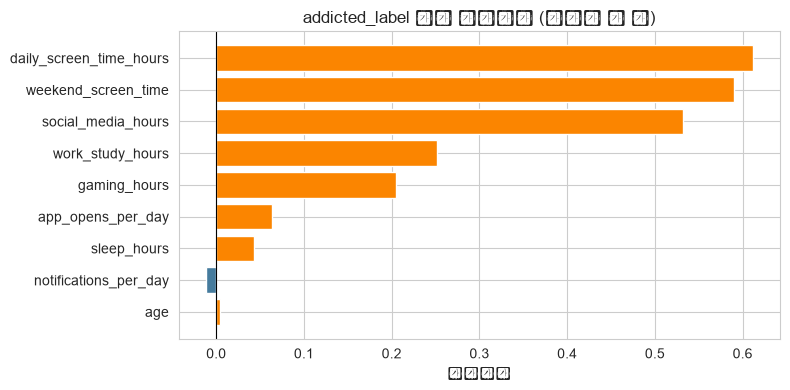

daily_screen_time_hours    0.6114
weekend_screen_time        0.5899
social_media_hours         0.5324
work_study_hours           0.2514
gaming_hours               0.2053
app_opens_per_day          0.0635
sleep_hours                0.0425
notifications_per_day     -0.0116
age                        0.0040
Name: addicted_label, dtype: float64


In [17]:
# 타깃과의 상관관계만 뽑아 순위를 매긴다
tgt_corr = corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#fb8500' if v > 0 else '#457b9d' for v in tgt_corr.values]
ax.barh(tgt_corr.index[::-1], tgt_corr.values[::-1], color=colors[::-1])
ax.axvline(0, color='black', lw=0.8)
ax.set_title(f'{TARGET} 과의 상관계수 (절댓값 큰 순)')
ax.set_xlabel('상관계수')
plt.tight_layout(); plt.show()

print(tgt_corr.round(4))

## 7. 결측 자체가 신호인가? (Missingness as a feature)

In [18]:
# "값이 비어 있다"는 사실이 타깃과 관련 있는지 확인한다.
# 예: 스크린타임을 응답하지 않은 사람이 실제로 더 중독되어 있을 수도 있다.
rows = []
for col in NUM_COLS + CAT_COLS:
    is_na = train[col].isnull()          # 결측이면 True
    rows.append({
        '변수': col,
        '결측 아닐 때 중독률': train.loc[~is_na, TARGET].mean(),
        '결측일 때 중독률'  : train.loc[is_na,  TARGET].mean(),
    })

na_effect = pd.DataFrame(rows)
na_effect['차이'] = na_effect['결측일 때 중독률'] - na_effect['결측 아닐 때 중독률']
na_effect = na_effect.sort_values('차이', key=abs, ascending=False).round(4)
na_effect

,변수,결측 아닐 때 중독률,결측일 때 중독률,차이
5,sleep_hours,0.7092,0.7134,0.0042
0,age,0.7093,0.7134,0.0042
7,app_opens_per_day,0.7090,0.7128,0.0038
1,daily_screen_time_hours,0.7091,0.7113,0.0022
8,weekend_screen_time,0.7092,0.7107,0.0015
3,gaming_hours,0.7092,0.7105,0.0013
4,work_study_hours,0.7093,0.7106,0.0013
6,notifications_per_day,0.7093,0.7102,0.0009
9,gender,0.7095,0.7088,-0.0007
10,stress_level,0.7095,0.7090,-0.0005


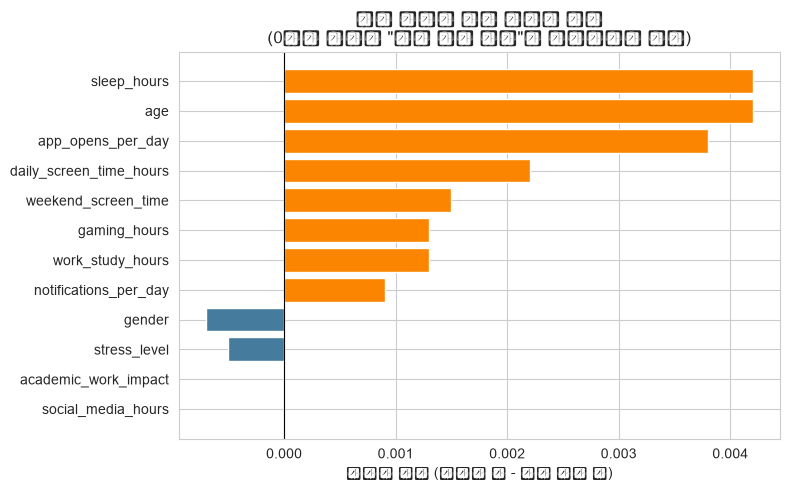

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
vals = na_effect['차이'].values[::-1]
names = na_effect['변수'].values[::-1]
colors = ['#fb8500' if v > 0 else '#457b9d' for v in vals]
ax.barh(names, vals, color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('결측 여부에 따른 중독률 차이\n(0에서 멀수록 "결측 표시 변수"가 유용하다는 신호)')
ax.set_xlabel('중독률 차이 (결측일 때 - 결측 아닐 때)')
plt.tight_layout(); plt.show()

### 해석

차이가 0에서 멀리 떨어진 변수가 있다면, 04단계에서
**결측 표시 변수(missing indicator)** 를 만들 가치가 있다는 뜻이다.

```python
train['social_media_hours_isna'] = train['social_media_hours'].isnull().astype(int)
```

이렇게 하면 "값을 채워 넣으면서 사라질 정보"를 별도 열로 보존할 수 있다.
반대로 차이가 모두 0에 가깝다면 결측은 완전 무작위(MCAR)로 발생한 것이라
이 피처는 도움이 되지 않는다.

---
## 📌 EDA 요약 및 다음 단계

### 데이터 개요
| 항목 | 내용 |
|---|---|
| 문제 유형 | 이진 분류 (중독 여부) — **확률**을 제출 |
| 예상 평가 지표 | ROC-AUC *(대회 Evaluation 탭에서 확인 필요)* |
| train | 691,369 행 × 13 피처 |
| test | 296,302 행 |
| 타깃 불균형 | 양성 70.9% : 음성 29.1% |

### 발견한 것
1. **결측치가 최대 난관** — 전 열 4~19%, 결측 없는 행은 39%뿐이라 행 삭제 불가
2. **train/test 결측 패턴이 유사** — 동일한 전처리를 적용해도 안전
3. **범주형 3개 모두 카테고리가 균등 분포** — 인코딩 부담이 적음
4. 상관관계·효과크기 순위로 **중요 변수 후보** 파악 완료

### 다음 단계 (02_preprocessing)
- [ ] 결측치 대치 전략 비교: 중앙값 vs 그룹별 중앙값 vs LightGBM 원본 처리
- [ ] 범주형 인코딩 (Label / One-Hot)
- [ ] Stratified K-Fold 검증 틀 만들기 — 불균형 데이터이므로 층화(stratified) 필수